In [2]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from random import shuffle
import re
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
os.chdir("C:/Users/11509/Desktop")

In [ ]:
def trim_alnblocks_discontig(blocks, winleft, winright, cutfrom, cutto):
    cutblocks = trim_alnblocks(blocks, winleft, winright)
    retblk = []
    for blkleft, blkright in cutblocks:
        retblk.append([transform_coords(blkleft, cutfrom, cutto),
                       transform_coords(blkright, cutfrom, cutto)])
    
    if len(retblk) > 2:
        center = [[bleft, bright] for bleft, bright in retblk[1:-1] if bleft < bright]
        return [retblk[0]] + center + [retblk[-1]]
    else:
        return retblk
    
def transform_coords(x, cutfrom, cutto):
    if x < cutfrom:
        return x
    elif x < cutto:
        return cutfrom
    else:
        return x - cutto + cutfrom

pat_cigarop = re.compile('([0-9]+)([A-Z])')
def convert_cigar_to_alnblocks(cigarstring, refstart):
    refstart = int(refstart)
    blks = [[refstart, refstart]]

    for length, op in pat_cigarop.findall(cigarstring):
        length = int(length)
        if op in 'MD':
            refstart += length
            blks[-1][1] = refstart
        elif op == 'N':
            refstart += length
            blks.append([refstart, refstart])
    return blks

def trim_alnblocks(blocks, winleft, winright):
    retblk = []
    leftcont = rightcont = False
    for left, right in blocks:
        if right <= winleft:
            leftcont = True
        elif left >= winright:
            rightcont = True
        else:
            retblk.append([max(winleft, left), min(winright, right)])

    if not retblk:
        return [[winleft, winleft], [winright, winright]]

    if leftcont and retblk[0][0] > winleft:
        retblk.insert(0, [winleft, winleft])
    if rightcont and retblk[-1][1] < winright:
        retblk.append([winright, winright])

    return retblk

In [ ]:
WINLEFT, WINRIGHT = 0, 30000
CUTLEFT, CUTRIGHT = 13467, 28273
TICKSTART = 0
WINLEFT_XFRM = transform_coords(WINLEFT, CUTLEFT, CUTRIGHT)
WINRIGHT_XFRM = transform_coords(WINRIGHT, CUTLEFT, CUTRIGHT)
MAJORTICKLABELS = list(np.arange(TICKSTART, CUTLEFT, 1000)) + list(np.arange(CUTRIGHT+100, WINRIGHT, 1000))
MAJORTICKS = [transform_coords(x, CUTLEFT, CUTRIGHT) for x in MAJORTICKLABELS]
MINORTICKLABELS = list(np.arange(TICKSTART, CUTLEFT, 200)) + list(np.arange(CUTRIGHT+100, WINRIGHT, 200))
MINORTICKS = [transform_coords(x, CUTLEFT, CUTRIGHT) for x in MINORTICKLABELS]
BARWIDTH = 0.8
BARCENTER = BARWIDTH / 2
BACKBONEWIDTH = 0.2
MINIMUM_MAPPED = 1000
VERTICAL_MARGIN = 1
NUMALIGNMENTS = 150
INTACT_END = transform_coords(29850, CUTLEFT, CUTRIGHT)
MINIMUM_FIRST_BLOCK_SIZE = 50
line = [transform_coords(x, CUTLEFT, CUTRIGHT) for x in [13467]]


In [5]:
coverage = \
pd.read_csv('SARS2-PRJNA675370-vero-24h-SRR13089344_orf1aton_coverage.txt', sep='\t',
            names=['chrom', 'pos', 'coverage'])
coverage

raw_loc = list(coverage['pos'])
need_loc = list(range(WINLEFT,WINRIGHT))
reduce_loc = [x for x in need_loc if x not in raw_loc]
reduce_loc_num = len(reduce_loc)
new_elements = pd.DataFrame({
    'chrom': ['NC_045512.2'] * reduce_loc_num,  
    'pos': reduce_loc,  
    'coverage': [0] * reduce_loc_num  
})
new_coverage = pd.concat([coverage, new_elements], ignore_index=True)
new_coverage = new_coverage.sort_values(by='pos')
new_coverage

depth = list(new_coverage['coverage'])
covblk1_x = np.arange(WINLEFT, CUTLEFT)
covblk2_x = np.arange(CUTRIGHT, WINRIGHT)
covblk1_x_xfrm = list(transform_coords(x, CUTLEFT, CUTRIGHT) for x in covblk1_x)
covblk2_x_xfrm = list(transform_coords(x, CUTLEFT, CUTRIGHT) for x in covblk2_x)
covblk1_y = depth[WINLEFT:CUTLEFT]
covblk2_y = depth[CUTRIGHT:WINRIGHT]

In [ ]:
intact_alignments = []
with open('SARS2-PRJNA675370-vero-24h-SRR13089344_orf1aton.info',"r") as alnfile:
    for aln in alnfile:
        aln = aln.strip().split()
        blocks = convert_cigar_to_alnblocks(aln[0], aln[1])
        blocks = trim_alnblocks_discontig(blocks, WINLEFT, WINRIGHT, CUTLEFT, CUTRIGHT)
        totalmapped = sum(right-left for left, right in blocks)
        if totalmapped < MINIMUM_MAPPED:
            continue
        elif blocks[-1][1] < INTACT_END:
            continue
        elif blocks[0][1] - blocks[0][0] < MINIMUM_FIRST_BLOCK_SIZE:
            continue
        elif blocks[0][1] < 2000:
            continue

        if len(blocks) > 1:
            gapft = max(
                (gapright - gapleft, gapleft, gapright)
                for (_, gapleft), (gapright, _) in zip(blocks[:-1], blocks[1:]))
        
            if gapft[0] < 100:
                gapft = (100000, -1, -blocks[0][0])
        else:
            gapft = (100000, -1, -blocks[0][0])

        intact_alignments.append((gapft[1:], blocks))

shuffle(intact_alignments)

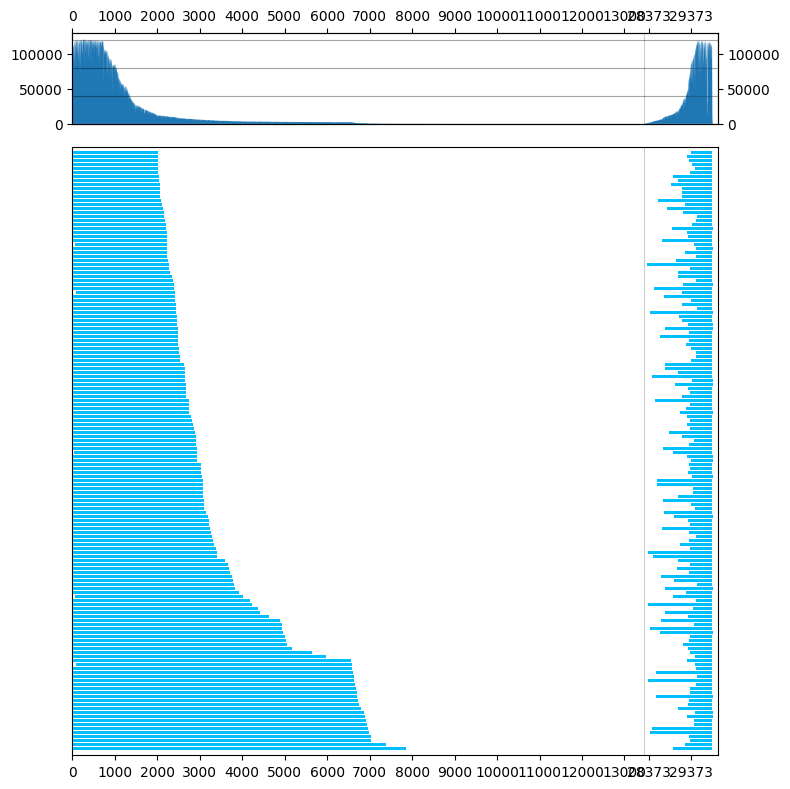

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(8, 8), gridspec_kw={'height_ratios': [1.5, 10]})
alnno = 0

ax = axes[1]
for alnno, (_, blocks) in enumerate(sorted(intact_alignments[:NUMALIGNMENTS])):
    #print(blocks)
    blkpatches = []
    for blkleft, blkright in blocks:
        if blkright - blkleft < 5:
            continue
        rect = Rectangle((blkleft, alnno), blkright-blkleft, 0.75)
        #起点坐标，宽度和高度
        blkpatches.append(rect)

    pc = PatchCollection(blkpatches, fc='#00BFFF', edgecolor='none', zorder=3)
    ax.add_collection(pc)

ax.set_xlim(WINLEFT_XFRM, WINRIGHT_XFRM)
ax.set_ylim(alnno + VERTICAL_MARGIN * 2, -VERTICAL_MARGIN)
ax.set_xticks(MAJORTICKS)
ax.set_xticklabels(MAJORTICKLABELS)
ax.axvline(line, c='black', lw=.8, zorder=5, alpha=.2)

plt.setp(ax.get_yticklines(), visible=False)
plt.setp(ax.get_yticklabels(), visible=False)

ax = axes[0]
ax.xaxis.tick_top()
ax.set_xlim(WINLEFT_XFRM, WINRIGHT_XFRM)
ax.set_xticks(MAJORTICKS)
ax.set_xticklabels(MAJORTICKLABELS)
ax.fill_between(covblk1_x_xfrm, 0, covblk1_y, zorder=3)
ax.set_ylim(0, 130000)

for i in np.arange(0, 120001, 40000):
    ax.axhline(i, c='black', lw=.8, zorder=5, alpha=.2)

ax = ax.twinx()
ax.fill_between(covblk2_x_xfrm, 0, covblk2_y, zorder=3)
#ax.set_yticks(np.arange(0, 600000, 100000))
ax.axvline(line, c='black', lw=.8, zorder=5, alpha=.2)
for i in np.arange(0, 120001, 40000):
    ax.axhline(i, c='black', lw=.8, zorder=5, alpha=.2)
ax.set_ylim(0, 130000)
    
plt.tight_layout()
plt.savefig('alignment-150-v2.pdf')